In [1]:
!pip -q install pulp

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd

PROJ = '/content/drive/MyDrive/airline-cx-copilot'
DATA = f'{PROJ}/data'

topics = pd.read_parquet(f'{DATA}/reviews_topics.parquet')
print(topics.shape)
assert 'topic_name' in topics.columns, 'Run notebook 2 through the naming and save cells first'
print(topics['topic_name'].value_counts())

Mounted at /content/drive
(8000, 21)
topic_name
Positive comfort & friendly crew             1114
Refunds, cancellations & customer service    1017
Flight delays & missed connections            927
Cabin service, meals & class                  675
Severe service failures & long delays         659
Seating, boarding & staff handling            652
Mixed airport & check-in experience           593
Positive crew & in-flight service             589
Asia-hub routes (Bangkok/Singapore)           559
Lost & delayed baggage                        513
Baggage fees & carry-on charges               380
China & Hong Kong routes                      322
Name: count, dtype: int64


In [3]:
# ============ ASSUMPTIONS - replace with your airline's real numbers ============
# Relative revenue per passenger (Economy = 1). NOT real money: swap in your own yield per cabin.
VALUE_INDEX = {'Economy Class': 1.0, 'Premium Economy': 1.6, 'Business Class': 4.0, 'First Class': 8.0}

# Probability that a handled complaint is recovered (passenger retained), and hours needed per case, by topic.
# Unknown topics fall back to the defaults below.
RECOVERY_P = {
    'Refunds, cancellations & customer service': 0.50,
    'Severe service failures & long delays': 0.25,
    'Lost & delayed baggage': 0.60,
    'Flight delays & missed connections': 0.35,
    'Baggage fees & carry-on charges': 0.40,
    'Seating, boarding & staff handling': 0.30,
}
HOURS = {
    'Refunds, cancellations & customer service': 1.0,
    'Severe service failures & long delays': 1.5,
    'Lost & delayed baggage': 1.5,
    'Flight delays & missed connections': 0.5,
    'Baggage fees & carry-on charges': 0.5,
    'Seating, boarding & staff handling': 0.5,
}
DEFAULT_P, DEFAULT_H = 0.40, 1.0

CAPACITY_SHARE = 0.25   # team capacity as a share of the hours needed to handle EVERY at-risk case
MIN_COVER = 0.10        # fairness rule: every segment gets at least this share of its cases handled
COMPLAINT_THRESHOLD = 0.30   # topics with recommend rate below this are treated as complaint topics

In [4]:
topic_rate = topics.groupby('topic_name')['recommended_bin'].mean()
complaint_topics = topic_rate[topic_rate < COMPLAINT_THRESHOLD].index.tolist()
print('Complaint topics used:', complaint_topics, '\n')

atrisk = topics[(topics['topic_name'].isin(complaint_topics)) & (topics['recommended_bin'] == 0)
                & topics['seat_type'].isin(VALUE_INDEX)]
seg = (atrisk.groupby(['topic_name', 'seat_type']).size().rename('cases').reset_index())
seg['value'] = seg['seat_type'].map(VALUE_INDEX)
seg['p'] = seg['topic_name'].map(RECOVERY_P).fillna(DEFAULT_P)
seg['hours'] = seg['topic_name'].map(HOURS).fillna(DEFAULT_H)
seg['gain_per_case'] = seg['value'] * seg['p']
seg['gain_per_hour'] = seg['gain_per_case'] / seg['hours']
seg['segment'] = seg['topic_name'] + ' | ' + seg['seat_type']
seg = seg.reset_index(drop=True)

TOTAL_HOURS = float((seg['cases'] * seg['hours']).sum())
CAPACITY = CAPACITY_SHARE * TOTAL_HOURS
print(f'{len(seg)} segments, {int(seg["cases"].sum())} at-risk cases')
print(f'Hours needed for all cases: {TOTAL_HOURS:.0f} | capacity: {CAPACITY:.0f} ({CAPACITY_SHARE:.0%})')
seg.sort_values('gain_per_hour', ascending=False).head(8)[['segment', 'cases', 'value', 'p', 'hours', 'gain_per_hour']].round(2)

Complaint topics used: ['Baggage fees & carry-on charges', 'Flight delays & missed connections', 'Lost & delayed baggage', 'Refunds, cancellations & customer service', 'Seating, boarding & staff handling', 'Severe service failures & long delays'] 

23 segments, 3707 at-risk cases
Hours needed for all cases: 3399 | capacity: 850 (25%)


,segment,cases,value,p,hours,gain_per_hour
2,Baggage fees & carry-on charges | First Class,2,8.0,0.40,0.5,6.4
6,Flight delays & missed connections | First Class,2,8.0,0.35,0.5,5.6
17,"Seating, boarding & staff handling | First Class",7,8.0,0.30,0.5,4.8
13,"Refunds, cancellations & customer service | Fi...",3,8.0,0.50,1.0,4.0
0,Baggage fees & carry-on charges | Business Class,6,4.0,0.40,0.5,3.2
4,Flight delays & missed connections | Business ...,29,4.0,0.35,0.5,2.8
15,"Seating, boarding & staff handling | Business ...",51,4.0,0.30,0.5,2.4
11,"Refunds, cancellations & customer service | Bu...",40,4.0,0.50,1.0,2.0


In [5]:
import pulp

def value_of(plan, s=seg):
    return float((s['gain_per_case'] * plan).sum())

def solve_plan(capacity, min_cover=0.0, s=seg):
    """Integer program: choose how many cases to handle in each segment to maximise expected retained value."""
    prob = pulp.LpProblem('recovery', pulp.LpMaximize)
    x = [pulp.LpVariable(f'x{i}', lowBound=0, upBound=int(c), cat='Integer') for i, c in enumerate(s['cases'])]
    prob += pulp.lpSum(float(g) * xi for g, xi in zip(s['gain_per_case'], x))
    prob += pulp.lpSum(float(h) * xi for h, xi in zip(s['hours'], x)) <= capacity
    for xi, c in zip(x, s['cases']):
        if min_cover > 0:
            prob += xi >= int(np.floor(min_cover * c))
    status = prob.solve(pulp.PULP_CBC_CMD(msg=0))
    if pulp.LpStatus[status] != 'Optimal':
        raise RuntimeError(f'Solver status: {pulp.LpStatus[status]} (capacity too small for the fairness rule?)')
    return np.array([xi.value() for xi in x])

def plan_proportional(capacity, s=seg):
    """Baseline 1: first-come-first-served. Every case equally likely to be handled."""
    frac = min(1.0, capacity / float((s['cases'] * s['hours']).sum()))
    return s['cases'].values * frac

def plan_premium_first(capacity, s=seg):
    """Baseline 2: business rule - serve First, then Business, then Premium Economy, then Economy."""
    order = s.assign(rank=s['seat_type'].map({'First Class': 0, 'Business Class': 1, 'Premium Economy': 2, 'Economy Class': 3}))
    order = order.sort_values(['rank', 'hours'])
    plan = np.zeros(len(s))
    left = capacity
    for i in order.index:
        n = min(float(s.loc[i, 'cases']), left / float(s.loc[i, 'hours']))
        plan[i] = max(n, 0.0)
        left -= plan[i] * float(s.loc[i, 'hours'])
        if left <= 1e-9:
            break
    return plan

plans = {
    'Proportional (first-come-first-served)': plan_proportional(CAPACITY),
    'Premium-first rule': plan_premium_first(CAPACITY),
    'Optimised (LP, no fairness rule)': solve_plan(CAPACITY, 0.0),
    f'Optimised (LP, min {MIN_COVER:.0%} coverage per segment)': solve_plan(CAPACITY, MIN_COVER),
}
summary = pd.DataFrame({'expected_retained_value': {k: value_of(v) for k, v in plans.items()},
                        'hours_used': {k: float((seg['hours'] * v).sum()) for k, v in plans.items()},
                        'cases_handled': {k: float(v.sum()) for k, v in plans.items()}}).round(1)
base = summary.loc['Proportional (first-come-first-served)', 'expected_retained_value']
summary['uplift_vs_proportional_%'] = ((summary['expected_retained_value'] / base - 1) * 100).round(1)
print(summary.to_string())
best = summary['expected_retained_value'].idxmax()
print(f'\nBest plan: {best}')

                                              expected_retained_value  hours_used  cases_handled  uplift_vs_proportional_%
Proportional (first-come-first-served)                          439.8       849.8          926.8                       0.0
Premium-first rule                                              802.4       849.8         1472.5                      82.4
Optimised (LP, no fairness rule)                                813.8       849.5         1518.0                      85.0
Optimised (LP, min 10% coverage per segment)                    739.2       849.5         1285.0                      68.1

Best plan: Optimised (LP, no fairness rule)


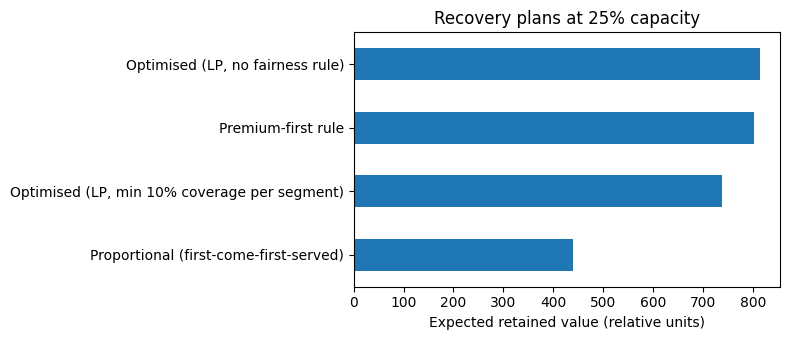

Price of the fairness rule: 9.2% of the optimum

                                                    segment  cases  gain_per_hour  handled_opt  share_opt  handled_fair  share_fair
              Baggage fees & carry-on charges | First Class      2           6.40          2.0       1.00           2.0        1.00
           Flight delays & missed connections | First Class      2           5.60          2.0       1.00           2.0        1.00
           Seating, boarding & staff handling | First Class      7           4.80          7.0       1.00           7.0        1.00
    Refunds, cancellations & customer service | First Class      3           4.00          3.0       1.00           3.0        1.00
           Baggage fees & carry-on charges | Business Class      6           3.20          6.0       1.00           6.0        1.00
        Flight delays & missed connections | Business Class     29           2.80         29.0       1.00          29.0        1.00
        Seating, boarding &

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.5))
summary['expected_retained_value'].sort_values().plot.barh(ax=ax)
ax.set_xlabel('Expected retained value (relative units)')
ax.set_title(f'Recovery plans at {CAPACITY_SHARE:.0%} capacity')
plt.tight_layout()
plt.show()

K_OPT = 'Optimised (LP, no fairness rule)'
K_FAIR = f'Optimised (LP, min {MIN_COVER:.0%} coverage per segment)'
K_PROP = 'Proportional (first-come-first-served)'
K_PREM = 'Premium-first rule'
price_of_fairness = 1 - summary.loc[K_FAIR, 'expected_retained_value'] / summary.loc[K_OPT, 'expected_retained_value']
print(f'Price of the fairness rule: {price_of_fairness:.1%} of the optimum\n')

alloc = seg.assign(handled_opt=plans[K_OPT], handled_fair=plans[K_FAIR])
alloc['share_opt'] = (alloc['handled_opt'] / alloc['cases']).round(2)
alloc['share_fair'] = (alloc['handled_fair'] / alloc['cases']).round(2)
alloc = alloc.sort_values('gain_per_hour', ascending=False)
print(alloc[['segment', 'cases', 'gain_per_hour', 'handled_opt', 'share_opt', 'handled_fair', 'share_fair']].round(2).to_string(index=False))

                proportional  premium_first  optimised  \
capacity_share                                           
0.10                   175.9          442.4      466.5   
0.15                   263.9          569.0      585.5   
0.25                   439.8          802.4      813.8   
0.35                   615.7          989.7      997.6   
0.50                   879.5         1244.6     1252.6   
0.75                  1319.3         1608.2     1612.6   
1.00                  1759.1         1759.1     1759.1   

                optimised_with_fairness  
capacity_share                           
0.10                              199.8  
0.15                              488.2  
0.25                              739.2  
0.35                              959.7  
0.50                             1218.5  
0.75                             1593.3  
1.00                             1759.1  


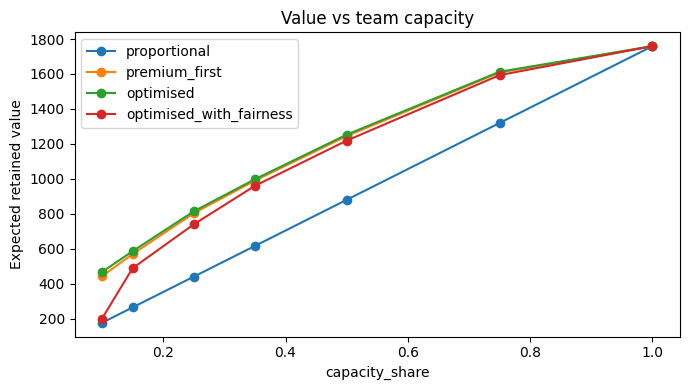

In [7]:
shares = [0.10, 0.15, 0.25, 0.35, 0.50, 0.75, 1.00]
rows = []
for sh in shares:
    cap = sh * TOTAL_HOURS
    try:
        fair = value_of(solve_plan(cap, MIN_COVER))
    except RuntimeError:
        fair = np.nan
    rows.append({'capacity_share': sh,
                 'proportional': value_of(plan_proportional(cap)),
                 'premium_first': value_of(plan_premium_first(cap)),
                 'optimised': value_of(solve_plan(cap, 0.0)),
                 'optimised_with_fairness': fair})
cap_df = pd.DataFrame(rows).set_index('capacity_share')
print(cap_df.round(1))

cap_df.plot(marker='o', figsize=(7, 4))
plt.ylabel('Expected retained value')
plt.title('Value vs team capacity')
plt.tight_layout()
plt.show()

In [8]:
rng = np.random.default_rng(7)
N_DRAWS = 1000
fixed = {'optimised': plans[K_OPT], 'optimised_with_fairness': plans[K_FAIR],
         'premium_first': plans[K_PREM], 'proportional': plans[K_PROP]}

vals = {k: [] for k in fixed}
for _ in range(N_DRAWS):
    v_mult = {k: rng.lognormal(0, 0.3) for k in VALUE_INDEX}          # about +/-30% error on each cabin's value
    p_mult = rng.uniform(0.7, 1.3, len(seg))                           # +/-30% error on each segment's recovery rate
    gain = seg['seat_type'].map(v_mult).values * seg['value'].values * np.clip(seg['p'].values * p_mult, 0, 1)
    for k, plan in fixed.items():
        vals[k].append(float((gain * plan).sum()))
mc = pd.DataFrame(vals)

def report(a, b):
    up = (mc[a] / mc[b] - 1) * 100
    print(f'{a} vs {b}: wins in {(mc[a] > mc[b]).mean():.1%} of draws | median uplift {up.median():.1f}% '
          f'(5th-95th pct {up.quantile(.05):.1f}% to {up.quantile(.95):.1f}%)')

report('optimised', 'proportional')
report('optimised', 'premium_first')
report('optimised_with_fairness', 'proportional')
report('optimised_with_fairness', 'premium_first')

optimised vs proportional: wins in 100.0% of draws | median uplift 87.1% (5th-95th pct 57.3% to 125.2%)
optimised vs premium_first: wins in 94.9% of draws | median uplift 1.3% (5th-95th pct -0.0% to 2.8%)
optimised_with_fairness vs proportional: wins in 100.0% of draws | median uplift 69.9% (5th-95th pct 45.1% to 103.1%)
optimised_with_fairness vs premium_first: wins in 0.0% of draws | median uplift -7.9% (5th-95th pct -11.2% to -4.0%)


In [9]:
alloc.to_csv(f'{DATA}/optimization_plan.csv', index=False)
mc.describe().to_csv(f'{DATA}/optimization_robustness.csv')
summary.to_csv(f'{DATA}/optimization_summary.csv')
cap_df.to_csv(f'{DATA}/optimization_capacity_curve.csv')
print('Saved: optimization_plan.csv, optimization_robustness.csv, optimization_summary.csv, optimization_capacity_curve.csv')

Saved: optimization_plan.csv, optimization_robustness.csv, optimization_summary.csv, optimization_capacity_curve.csv
